<a href="https://colab.research.google.com/github/Azidian/Inteligencia_Artificial/blob/main/Actividades/09_Lecture03_csp/05_csp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 — Problemas de Satisfacción de Restricciones

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

- representar un CSP mediante variables, dominios y restricciones;
- resolver un problema de horarios con backtracking;
- medir el efecto de MRV, heurística de grado y forward checking;
- diferenciar satisfacción de restricciones y optimización.

![Descripción](https://drive.google.com/uc?export=view&id=1opAXyVoZi8Orca1oSZ3zRk-vG_d868c1)



## 1. Programación de exámenes

Siete exámenes deben asignarse a tres días. Algunos pares comparten estudiantes y no pueden programarse el mismo día.

Un CSP se define por:

- variables $X_1,\dots,X_n$;
- dominios $D_1,\dots,D_n$;
- restricciones que determinan qué asignaciones son válidas.

In [1]:
from collections import defaultdict
import matplotlib.pyplot as plt

VARIABLES = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
DAYS = ['Lunes', 'Martes', 'Miércoles']
CONSTRAINTS = [
    ('A', 'B'), ('A', 'C'), ('B', 'C'), ('B', 'D'), ('B', 'E'),
    ('C', 'E'), ('C', 'F'), ('D', 'E'), ('E', 'F'), ('E', 'G'),
    ('F', 'G')
]

neighbors = defaultdict(set)
for x, y in CONSTRAINTS:
    neighbors[x].add(y)
    neighbors[y].add(x)

print('Vecinos por variable:')
for var in VARIABLES:
    print(var, sorted(neighbors[var]))

Vecinos por variable:
A ['B', 'C']
B ['A', 'C', 'D', 'E']
C ['A', 'B', 'E', 'F']
D ['B', 'E']
E ['B', 'C', 'D', 'F', 'G']
F ['C', 'E', 'G']
G ['E', 'F']


## 2. Consistencia

Una asignación parcial es consistente cuando ningún par ya asignado viola una restricción.

In [2]:
def consistent(assignment):
    for x, y in CONSTRAINTS:
        if x in assignment and y in assignment and assignment[x] == assignment[y]:
            return False
    return True

print(consistent({'A': 'Lunes', 'B': 'Martes'}))
print(consistent({'A': 'Lunes', 'B': 'Lunes'}))

True
False


## 3. Backtracking básico

Construimos la asignación una variable a la vez. Cuando una elección conduce a una contradicción, retrocedemos.

In [3]:
def backtracking_basic(variables, domains):
    stats = {'calls': 0, 'failures': 0}

    def backtrack(assignment):
        stats['calls'] += 1
        if len(assignment) == len(variables):
            return assignment.copy()

        var = next(v for v in variables if v not in assignment)
        for value in domains[var]:
            assignment[var] = value
            if consistent(assignment):
                result = backtrack(assignment)
                if result is not None:
                    return result
            assignment.pop(var)

        stats['failures'] += 1
        return None

    return backtrack({}), stats

domains = {var: DAYS.copy() for var in VARIABLES}
solution_basic, stats_basic = backtracking_basic(VARIABLES, domains)
print('Solución:', solution_basic)
print('Estadísticas:', stats_basic)

Solución: {'A': 'Lunes', 'B': 'Martes', 'C': 'Miércoles', 'D': 'Miércoles', 'E': 'Lunes', 'F': 'Martes', 'G': 'Miércoles'}
Estadísticas: {'calls': 9, 'failures': 1}


## 4. MRV y heurística de grado

**MRV** selecciona la variable no asignada con menos valores disponibles. En caso de empate, la heurística de grado prioriza la variable que restringe a más variables no asignadas.

In [4]:
def legal_values(var, assignment, domains):
    return [value for value in domains[var]
            if all(assignment.get(n) != value for n in neighbors[var])]


def select_unassigned_variable(assignment, domains):
    unassigned = [v for v in VARIABLES if v not in assignment]
    return min(
        unassigned,
        key=lambda v: (
            len(legal_values(v, assignment, domains)),
            -sum(n not in assignment for n in neighbors[v])
        )
    )

assignment = {'A': 'Lunes'}
print('Siguiente variable:', select_unassigned_variable(assignment, domains))

Siguiente variable: B


## 5. Forward Checking

Después de asignar una variable, eliminamos ese valor de los dominios de sus vecinos no asignados. Si algún dominio queda vacío, detectamos el fracaso antes de profundizar.

In [5]:
def backtracking_with_inference(initial_domains):
    stats = {'calls': 0, 'failures': 0, 'pruned_values': 0}

    def backtrack(assignment, domains):
        stats['calls'] += 1
        if len(assignment) == len(VARIABLES):
            return assignment.copy()

        var = select_unassigned_variable(assignment, domains)
        for value in legal_values(var, assignment, domains):
            new_assignment = assignment.copy()
            new_assignment[var] = value
            new_domains = {v: vals.copy() for v, vals in domains.items()}
            new_domains[var] = [value]

            valid = True
            for neighbor in neighbors[var]:
                if neighbor in new_assignment:
                    continue
                if value in new_domains[neighbor]:
                    new_domains[neighbor].remove(value)
                    stats['pruned_values'] += 1
                if not new_domains[neighbor]:
                    valid = False
                    break

            if valid:
                result = backtrack(new_assignment, new_domains)
                if result is not None:
                    return result

        stats['failures'] += 1
        return None

    return backtrack({}, {v: vals.copy() for v, vals in initial_domains.items()}), stats

solution_fc, stats_fc = backtracking_with_inference(domains)
print('Solución:', solution_fc)
print('Backtracking básico:', stats_basic)
print('MRV + grado + forward checking:', stats_fc)

Solución: {'E': 'Lunes', 'B': 'Martes', 'C': 'Miércoles', 'F': 'Martes', 'A': 'Lunes', 'D': 'Miércoles', 'G': 'Miércoles'}
Backtracking básico: {'calls': 9, 'failures': 1}
MRV + grado + forward checking: {'calls': 8, 'failures': 0, 'pruned_values': 11}


## 6. Verificación automática

In [6]:
def validate_solution(solution):
    if solution is None or set(solution) != set(VARIABLES):
        return False
    if any(solution[var] not in DAYS for var in VARIABLES):
        return False
    return all(solution[x] != solution[y] for x, y in CONSTRAINTS)

print('Solución válida:', validate_solution(solution_fc))

Solución válida: True


## 7. CSP versus optimización

En este problema, cualquier horario consistente es una solución. Si además quisiéramos minimizar el número de días utilizados o equilibrar la cantidad de exámenes por día, agregaríamos una **función objetivo** y el problema se convertiría en una variante de optimización con restricciones.

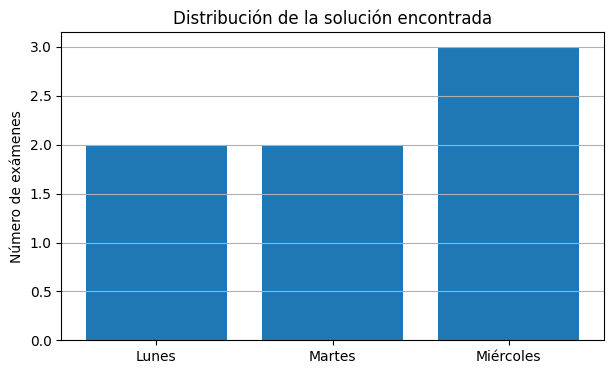

In [7]:
counts = {day: list(solution_fc.values()).count(day) for day in DAYS}
plt.figure(figsize=(7, 4))
plt.bar(counts.keys(), counts.values())
plt.ylabel('Número de exámenes')
plt.title('Distribución de la solución encontrada')
plt.grid(True, axis='y')
plt.show()

## Actividades

### Actividad 1 — Dos días

Cambia el dominio para usar solo lunes y martes. ¿Existe solución? Relaciona el resultado con el coloreo de grafos.

In [11]:
# TODO: prueba el problema con dos días.
two_day_domains = {var: ['Lunes', 'Martes'] for var in VARIABLES}
solution_two_days, stats_two_days = backtracking_with_inference(two_day_domains)

print('Solución (2 días):', solution_two_days)
print('Estadísticas:', stats_two_days)

Solución (2 días): None
Estadísticas: {'calls': 3, 'failures': 3, 'pruned_values': 12}


### Actividad 2 — Restricción unaria

El examen `A` solo puede realizarse el lunes. Modifica su dominio antes de iniciar el backtracking.

In [16]:
# TODO: crea los dominios con la restricción A = Lunes.
restricted_domains = {var: DAYS.copy() for var in VARIABLES}
restricted_domains['A'] = ['Lunes']

solution_restricted, stats_restricted = backtracking_with_inference(restricted_domains)

print('Solución (A = Lunes):', solution_restricted)
print('Estadísticas:', stats_restricted)

Solución (A = Lunes): {'A': 'Lunes', 'B': 'Martes', 'C': 'Miércoles', 'E': 'Lunes', 'F': 'Martes', 'D': 'Miércoles', 'G': 'Miércoles'}
Estadísticas: {'calls': 8, 'failures': 0, 'pruned_values': 11}


### Actividad 3 — Orden de valores

Implementa **Least Constraining Value (LCV)**: prueba primero el valor que elimina menos opciones de los vecinos.

In [14]:
def order_domain_values(var, assignment, domains):
    """
    Retorna los valores legales para 'var' ordenados de menor a mayor impacto
    (LCV: ordena según cuántas opciones elimina en los dominios de los vecinos no asignados).
    """
    def count_eliminated_options(val):
        eliminated = 0
        for neighbor in neighbors[var]:
            if neighbor not in assignment and val in domains[neighbor]:
                eliminated += 1
        return eliminated

    legals = legal_values(var, assignment, domains)
    # Ordenar los valores legales priorizando aquellos con menor conteo de opciones eliminadas
    return sorted(legals, key=count_eliminated_options)


# Bloque de prueba de la función order_domain_values
test_assignment = {'A': 'Lunes'}
print("Valores legales ordenados con LCV para 'B':", order_domain_values('B', test_assignment, domains))

Valores legales ordenados con LCV para 'B': ['Martes', 'Miércoles']


### Actividad 4 — Optimización sobre el CSP

Entre todas las soluciones válidas, busca una que minimice el desbalance:

$$
\max_d n_d-\min_d n_d
$$

where $n_d$ is the number of exams assigned to day $d$. Puedes enumerar todas las soluciones con backtracking y conservar la mejor.

In [15]:
def find_all_solutions(variables, initial_domains):
    """Retorna una lista con todas las soluciones válidas posibles."""
    all_solutions = []

    def backtrack(assignment, domains):
        if len(assignment) == len(variables):
            all_solutions.append(assignment.copy())
            return

        var = select_unassigned_variable(assignment, domains)
        for value in order_domain_values(var, assignment, domains):
            new_assignment = assignment.copy()
            new_assignment[var] = value
            new_domains = {v: vals.copy() for v, vals in domains.items()}
            new_domains[var] = [value]

            valid = True
            for neighbor in neighbors[var]:
                if neighbor in new_assignment:
                    continue
                if value in new_domains[neighbor]:
                    new_domains[neighbor].remove(value)
                if not new_domains[neighbor]:
                    valid = False
                    break

            if valid:
                backtrack(new_assignment, new_domains)

    backtrack({}, {v: vals.copy() for v, vals in initial_domains.items()})
    return all_solutions


# Enumeración y evaluación del desbalance
all_solutions = find_all_solutions(VARIABLES, domains)

def calculate_imbalance(sol):
    counts = [list(sol.values()).count(day) for day in DAYS]
    return max(counts) - min(counts)

best_solution = min(all_solutions, key=calculate_imbalance)
best_imbalance = calculate_imbalance(best_solution)

print(f"Total de soluciones válidas encontradas: {len(all_solutions)}")
print(f"Desbalance mínimo alcanzado: {best_imbalance}")
print("Mejor solución obtenida:", best_solution)
print("Distribución por día:", {day: list(best_solution.values()).count(day) for day in DAYS})

Total de soluciones válidas encontradas: 6
Desbalance mínimo alcanzado: 1
Mejor solución obtenida: {'E': 'Lunes', 'B': 'Martes', 'C': 'Miércoles', 'F': 'Martes', 'A': 'Lunes', 'D': 'Miércoles', 'G': 'Miércoles'}
Distribución por día: {'Lunes': 2, 'Martes': 2, 'Miércoles': 3}


## Preguntas de cierre

1. ¿Qué información utiliza MRV para seleccionar una variable?

R: MRV (Minimum Remaining Values o Valores Restantes Mínimos) examina el tamaño del dominio actual de las variables no asignadas aún y selecciona la variable con el menor número de valores disponibles. Esto aplica el principio de "fail-first" (fallar lo antes posible), reduciendo la profundidad del árbol de búsqueda.

2. ¿Forward checking evita completamente el backtracking?

R: No. Forward checking anticipa inconsistencias a un paso de distancia eliminando valores de los dominios de los vecinos directos de la variable recién asignada. Sin embargo, no detecta inconsistencias entre variables no asignadas que estén a dos o más pasos de distancia (como inconsistencias de arcos futuros), por lo que aún se pueden tomar decisiones erróneas que requerirán backtracking más adelante.


3. ¿Una solución consistente parcial es necesariamente extensible a una solución completa?

R: No. Una asignación parcial puede ser consistente con todas las restricciones evaluadas hasta ese momento, pero haber entrado en un callejón sin salida (dead end). Esto ocurre cuando elecciones previas hacen imposible asignar valores válidos a las variables restantes sin violar alguna restricción.

4. ¿Cuándo un CSP se convierte en un problema de optimización?

R: Un CSP se convierte en un Problema de Optimización con Restricciones (COP) cuando, además de satisfacer todas las restricciones duras, se define una función objetivo (Ej: minimizar el número de días utilizados o el desbalance de exámenes por día). En este escenario, no basta con encontrar cualquier asignación factible, sino que se busca la asignación factible que maximice o minimice dicha función.